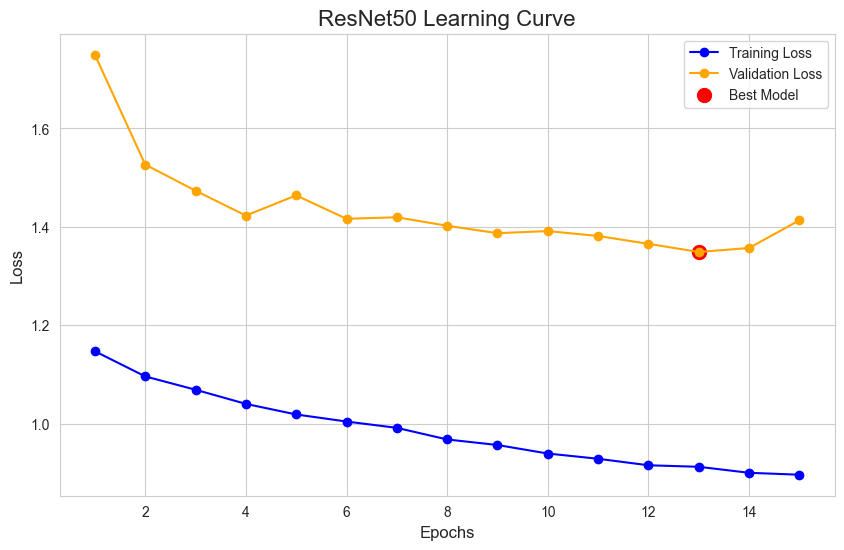

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Կարդում ենք լոգերը
log_path = '../models/training_log.csv'
df = pd.read_csv(log_path)

# Գծում ենք գրաֆիկը
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

plt.plot(df['epoch'], df['train_loss'], label='Training Loss', marker='o', color='blue')
plt.plot(df['epoch'], df['val_loss'], label='Validation Loss', marker='o', color='orange')

# Նշենք ամենալավ կետը (մինիմում val_loss-ը)
best_epoch = df.loc[df['val_loss'].idxmin()]
plt.scatter(best_epoch['epoch'], best_epoch['val_loss'], color='red', s=100, label='Best Model')

plt.title('ResNet50 Learning Curve', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

Evaluation

In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from torchvision import models, transforms
from sklearn.metrics import roc_auc_score
import sys
import os

sys.path.append(os.path.abspath('../src'))

from dataset import ChestXrayDataset
from dataset import ChestXrayDataset
from tqdm import tqdm

# --- CONFIG ---
BATCH_SIZE = 16 # Evaluation-ի համար կարող ենք շատ դնել
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "../models/resnet50_best.pth" # Վերցնում ենք լավագույնը

LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

def evaluate_model():
    print(f"✅ Evaluating on device: {DEVICE}")

    # Transforms (Նույնը, ինչ validation-ում)
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Միայն Test set-ն ենք օգտագործում
    test_dataset = ChestXrayDataset(
        data_dir=r'C:\Users\srbuh\Desktop\Medical_AI_Diagnosis\data\images',
        csv_file=r'C:\Users\srbuh\Desktop\Medical_AI_Diagnosis\data\Data_Entry_2017.csv',
        split_list_file=r'C:\Users\srbuh\Desktop\Medical_AI_Diagnosis\data\test_list.txt',
        transform=val_transform
    )

    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Load Model
    print("⏳ Loading Model...")
    model = models.resnet50(pretrained=False) # Pretrained պետք չի, մենք մերն ենք բեռնում
    model.fc = torch.nn.Linear(model.fc.in_features, 14)

    # Բեռնում ենք մեր սովորած կշիռները
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()

    # Prediction Loop
    y_true = []
    y_pred = []

    print("🚀 Starting Prediction...")
    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images = images.to(DEVICE)
            outputs = model(images)

            # Sigmoid, որ ստանանք հավանականություններ (0-ից 1)
            probs = torch.sigmoid(outputs)

            y_true.append(labels.cpu().numpy())
            y_pred.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # Calculate AUC for each class
    print("\n📊 RESULTS (AUC-ROC Score):")
    print("-" * 30)

    aucs = []
    for i, label in enumerate(LABELS):
        try:
            auc = roc_auc_score(y_true[:, i], y_pred[:, i])
            aucs.append(auc)
            print(f"{label:20}: {auc:.4f}")
        except ValueError:
            print(f"{label:20}: Error (Not enough samples)")

    print("-" * 30)
    print(f"🏆 Average AUC: {np.mean(aucs):.4f}")

if __name__ == "__main__":
    evaluate_model()

✅ Evaluating on device: cpu
⏳ Loading Model...


C:\Users\srbuh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\srbuh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


🚀 Starting Prediction...


100%|██████████| 1600/1600 [48:13<00:00,  1.81s/it]



📊 RESULTS (AUC-ROC Score):
------------------------------
Atelectasis         : 0.7316
Cardiomegaly        : 0.8484
Consolidation       : 0.7168
Edema               : 0.8134
Effusion            : 0.7983
Emphysema           : 0.8600
Fibrosis            : 0.7887
Hernia              : 0.8779
Infiltration        : 0.6845
Mass                : 0.7765
Nodule              : 0.7036
Pleural_Thickening  : 0.7373
Pneumonia           : 0.6761
Pneumothorax        : 0.8222
------------------------------
🏆 Average AUC: 0.7739
